# FIGS3: Closed-loop forward simulation with the learned versus the analytical Appell energy

This notebook regenerates Supplementary Figure 3 from the packaged data archive `FIGS3.zip` or `FIGS3`.
The archive must be in the same folder as this notebook. Every plotted value is read from the archive, the notebook asserts that all 600 archived values are drawn and that none falls outside its axes, then saves `FIGS3.svg`, `FIGS3.pdf` and `FIGS3.png`.


All 600 values lie inside their axes; ranges position 0.002-0.1, velocity 0.005-0.5, acceleration 0.02-5; analytical lower in position/J1 26, position/J2 29, velocity/J1 29, velocity/J2 28, acceleration/J1 26, acceleration/J2 28 of 50
Saved FIGS3.svg
Saved FIGS3.pdf


Saved FIGS3.png


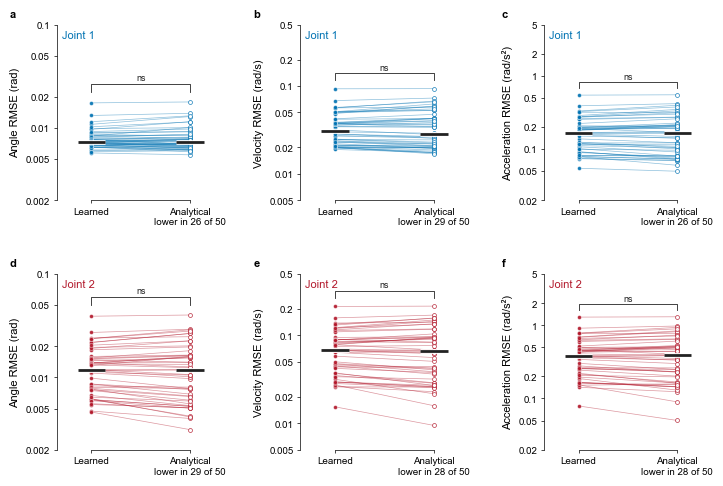

600 archived values, 600 drawn, 50 trajectories per model, quantity and joint.
Data provenance:
  trajectories = 50, states per trajectory = 2500
  solver configuration = {'sampled_acceleration_vectors_N': 16, 'uniform_acceleration_bound_B_rad_s2': 15.0, 'adam_refinement_steps_A': 10, 'adam_learning_rate': 0.1, 'lambda_regularization': 0.1, 'warmup_steps': 5, 'simulation_dt_s': 0.002, 'steps': 2500, 'num_trajectories': 50, 'seed': 23, 'gravity_m_s2': 9.81, 'params': {'m1': 1.0, 'm2': 1.0, 'l1': 1.0, 'l2': 1.0}, 'objective': 'analytical Gibbs-Appell S + G(q).ddq + lambda ||ddq - ddq_prev||^2', 'integrator': 'semi-implicit Euler'}
Statistics (primary test, FDR-adjusted):
    quantity joint_label             test_name  statistic  p_value  fdr_q_value  median_learned  median_analytical  median_ratio_analytical_over_learned
    position     Joint 1 Kruskal-Wallis H-test   0.368032 0.544079     0.939553        0.007375           0.007279                              0.986974
    position    

In [1]:
from pathlib import Path
import json
import zipfile

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# Load packaged data. FIGS3.zip or FIGS3 must be in the same folder as this notebook.
# -----------------------------------------------------------------------------
DATA_ARCHIVE = Path("FIGS3.zip")
if not DATA_ARCHIVE.exists():
    DATA_ARCHIVE = Path("FIGS3")
if not DATA_ARCHIVE.exists():
    raise FileNotFoundError(
        "Could not find FIGS3.zip or FIGS3 in the current folder. "
        "Place the data archive in the same folder as FIGS3.ipynb."
    )

if DATA_ARCHIVE.is_dir():
    def open_member(name):
        return open(DATA_ARCHIVE / name, "rb")
else:
    _archive = zipfile.ZipFile(DATA_ARCHIVE)

    def open_member(name):
        return _archive.open(name)

rmse_table = pd.read_csv(open_member("figs3_rmse_values.csv"))
stats_table = pd.read_csv(open_member("figs3_statistics.csv"))
metadata = json.load(open_member("figs3_metadata.json"))


# -----------------------------------------------------------------------------
# Supplementary Fig. 3: paired comparison of the closed-loop forward simulation with
# the learned Appell energy and with the analytical Gibbs-Appell function in the same
# solver. Both runs used the same 50 initial states and reference trajectories, so
# each trajectory is one line from its error with the learned energy (filled marker)
# to its error with the analytical energy (open marker); one panel per joint (rows)
# and quantity (columns). Heavy black bars are medians. 'ns' marks a Benjamini-
# Hochberg-adjusted q value of the primary test (figs3_statistics.csv) at or above
# 0.05, a single asterisk would mark one below it. All inputs come from FIGS3.zip;
# all 600 values are drawn, and assertions verify that every axis encloses them.
# -----------------------------------------------------------------------------
BLUE, RED, NEUTRAL = "#0072B2", "#B2182B", "#222222"
JOINTS = ["J1", "J2"]; JL = {"J1": "Joint 1", "J2": "Joint 2"}; JC = {"J1": BLUE, "J2": RED}
QUANT = [("position", "Angle RMSE (rad)"), ("velocity", "Velocity RMSE (rad/s)"), ("acceleration", "Acceleration RMSE (rad/s²)")]
mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7, "axes.labelsize": 8, "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.linewidth": 0.5, "xtick.major.width": 0.5, "ytick.major.width": 0.5, "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "xtick.major.pad": 2.5, "ytick.major.pad": 2.5, "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
    "savefig.bbox": "standard", "figure.dpi": 100, "savefig.dpi": 600,
})
T125 = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10]
def tight(v):
    # tightest labelled ticks enclosing all values, with headroom above the maximum for the bracket
    return max(t for t in T125 if t <= np.min(v)), min(t for t in T125 if t >= np.max(v) * 1.7)
def label(q, j): return "ns" if float(stats_table.loc[(stats_table.quantity == q) & (stats_table.joint == j), "fdr_q_value"].iloc[0]) >= 0.05 else "*"
vals = {(q, j, m): rmse_table[(rmse_table.quantity == q) & (rmse_table.joint == j) & (rmse_table.model == m)].sort_values("trajectory").rmse.to_numpy(float)
        for q, _ in QUANT for j in JOINTS for m in ("learned_S", "analytical_S")}
assert all(v.size == 50 for v in vals.values())

XL, XA = 0.0, 1.0
fig, axes = plt.subplots(2, 3, figsize=(7.2, 5.0), sharey="col")
fig.subplots_adjust(left=0.075, right=0.985, top=0.95, bottom=0.10, wspace=0.45, hspace=0.42)
limits = {}
for ci, (q, ylabel) in enumerate(QUANT):
    lo, hi = tight(np.r_[vals[(q, "J1", "learned_S")], vals[(q, "J1", "analytical_S")], vals[(q, "J2", "learned_S")], vals[(q, "J2", "analytical_S")]]); limits[q] = (lo, hi)
    for ri, j in enumerate(JOINTS):
        ax = axes[ri, ci]; a, b = vals[(q, j, "learned_S")], vals[(q, j, "analytical_S")]; lower = b < a
        for i in range(a.size):
            ax.plot([XL, XA], [a[i], b[i]], color=JC[j], lw=0.5, alpha=0.45, zorder=2)
        ax.scatter(np.full(a.size, XL), a, s=8, color=JC[j], edgecolors="white", linewidths=0.3, alpha=0.9, zorder=3)
        ax.scatter(np.full(b.size, XA), b, s=8, facecolors="white", edgecolors=JC[j], linewidths=0.5, alpha=0.9, zorder=3)
        for x, m in ((XL, np.median(a)), (XA, np.median(b))):
            ax.plot([x - 0.14, x + 0.14], [m, m], color=NEUTRAL, lw=2.0, solid_capstyle="butt", zorder=6, path_effects=[pe.withStroke(linewidth=3.4, foreground="white")])
        top = max(a.max(), b.max())
        ax.plot([XL, XL, XA, XA], [top * 1.25, top * 1.5, top * 1.5, top * 1.25], color=NEUTRAL, lw=0.6, zorder=6)
        ax.text(0.5, top * 1.55, label(q, j), ha="center", va="bottom", fontsize=8 if label(q, j) == "*" else 6.5, color=NEUTRAL)
        ax.text(0.03, 0.97, JL[j], transform=ax.transAxes, ha="left", va="top", fontsize=8, color=JC[j])
        ax.set_yscale("log"); ax.set_ylim(lo, hi); ax.set_xlim(-0.35, 1.35)
        ax.set_xticks([XL, XA]); ax.set_xticklabels(["Learned", f"Analytical\nlower in {int(lower.sum())} of {a.size}"])
        for s in ("top", "right"): ax.spines[s].set_visible(False)
        ax.spines["bottom"].set_bounds(XL, XA)
        if ci == 0: ax.set_ylabel(ylabel)
    for ri in range(2):
        ax = axes[ri, ci]; ax.yaxis.set_major_locator(FixedLocator([t for t in T125 if lo <= t <= hi])); ax.yaxis.set_minor_locator(NullLocator())
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
        if ci > 0: ax.set_ylabel(ylabel)
fig.canvas.draw(); _rend = fig.canvas.get_renderer()
for letter, ax in zip("abcdef", axes.flatten()):
    bb = ax.get_tightbbox(_rend).transformed(fig.transFigure.inverted())
    fig.text(bb.x0, bb.y1 + 0.004, letter, fontsize=8, fontweight="bold", ha="left", va="bottom")

# Range check: nothing plotted outside its axes
for q, (lo, hi) in limits.items():
    v = np.concatenate([vals[(q, j, m)] for j in JOINTS for m in ("learned_S", "analytical_S")]); assert ((v >= lo) & (v <= hi)).all(), q
print("All 600 values lie inside their axes; ranges " + ", ".join(f"{q} {lo}-{hi}" for q, (lo, hi) in limits.items()) + "; analytical lower in "
      + ", ".join(f"{q}/{j} {int((vals[(q, j, 'analytical_S')] < vals[(q, j, 'learned_S')]).sum())}" for q, _ in QUANT for j in JOINTS) + " of 50")
for ext in ("svg", "pdf", "png"):
    path = Path(f"FIGS3.{ext}")
    fig.savefig(path, facecolor="white")
    print(f"Saved {path}")
plt.show()

# ---- every archived value is drawn exactly once ----------------------------------------
_n_rows = len(rmse_table); _n_drawn = sum(v.size for v in vals.values())
assert _n_rows == 600 == _n_drawn, (_n_rows, _n_drawn)
assert set(rmse_table.model) == {"learned_S", "analytical_S"} and set(rmse_table.quantity) == {q for q, _ in QUANT} and set(rmse_table.joint) == set(JOINTS)
assert rmse_table.groupby(["model", "quantity", "joint"]).trajectory.nunique().eq(50).all()
print(f"{_n_rows} archived values, {_n_drawn} drawn, 50 trajectories per model, quantity and joint.")
print("Data provenance:")
print(f"  trajectories = {metadata['reference']['num_trajectories']}, states per trajectory = {metadata['reference']['states_per_trajectory']}")
print(f"  solver configuration = {metadata['solver_configuration']}")
print("Statistics (primary test, FDR-adjusted):")
print(stats_table[["quantity", "joint_label", "test_name", "statistic", "p_value", "fdr_q_value",
                   "median_learned", "median_analytical", "median_ratio_analytical_over_learned"]].to_string(index=False))
